# Line Segment Detection

We want to detect fast vs slow barcoding using ground truth markings, extract line markings from JPGs, and add metadata from E2Es. 

Fast: `08, 09, 12, 41, 49`

Slow: `17, 23, 35, 36, 47`

So the workflow goes:

```
annotated JPGs
→ extract red/yellow line coordinates
→ create annotation dataframe

E2E files
→ extract patient, B-scan metadata, native image info, layers
→ create E2E dataframe

annotation dataframe + E2E dataframe
→ merge on patient_id + bscan_index
```

The annotation extractor is the first step, and should extract a table with id, scan, structure (EA, barcode), width, and height

Once that is done, it can be merged with metadata, and then follow
```
Original B-scan
↓
EA annotation (green)
Barcode annotation (yellow)
↓
Binary masks
↓
Measurements
```

Test Data:
* the one with no markings is EA8000.jpg
* the one with red markings is EA8011.jpg
* the one with yellow markings is EA8041.jpg
* the one with both markings is EA8043.jpg.

Should work:

whole JPG, crop right OCT panel, HSV threshold, connected components, estimate line endpoints, measure lengths

Once this works then we can merge with metadata

In [ ]:
!pip install opencv-python

In [50]:
from pathlib import Path

import cv2
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

PATIENT_ID = "008"

ANNO_DIR = Path("../data/heyex/anno") / PATIENT_ID

TEST_FILES = {
    "none": ANNO_DIR / "EA8000.jpg",
    "red_only": ANNO_DIR / "EA8011.jpg",
    "yellow_only": ANNO_DIR / "EA8041.jpg",
    "both": ANNO_DIR / "EA8043.jpg",
    "multiple": ANNO_DIR / "EA8046.jpg",
}

for expected_label, path in TEST_FILES.items():
    print(
        f"{expected_label:12s} | "
        f"{path.name:12s} | "
        f"exists={path.exists()}"
    )

none         | EA8000.jpg   | exists=True
red_only     | EA8011.jpg   | exists=True
yellow_only  | EA8041.jpg   | exists=True
both         | EA8043.jpg   | exists=True
multiple     | EA8046.jpg   | exists=True


In [51]:
def load_image(path: Path) -> np.ndarray:
    """
    Load a JPG using OpenCV.

    Returns
    -------
    np.ndarray
        Image in OpenCV BGR format.
    """
    image = cv2.imread(str(path))

    if image is None:
        raise FileNotFoundError(f"Could not load image: {path}")

    return image


images = {
    expected_label: load_image(path)
    for expected_label, path in TEST_FILES.items()
}

for expected_label, image in images.items():
    height, width = image.shape[:2]

    print(
        f"{expected_label:12s} | "
        f"shape={image.shape} | "
        f"height={height}, width={width}"
    )

none         | shape=(596, 1008, 3) | height=596, width=1008
red_only     | shape=(596, 1008, 3) | height=596, width=1008
yellow_only  | shape=(596, 1008, 3) | height=596, width=1008
both         | shape=(596, 1008, 3) | height=596, width=1008
multiple     | shape=(596, 1008, 3) | height=596, width=1008


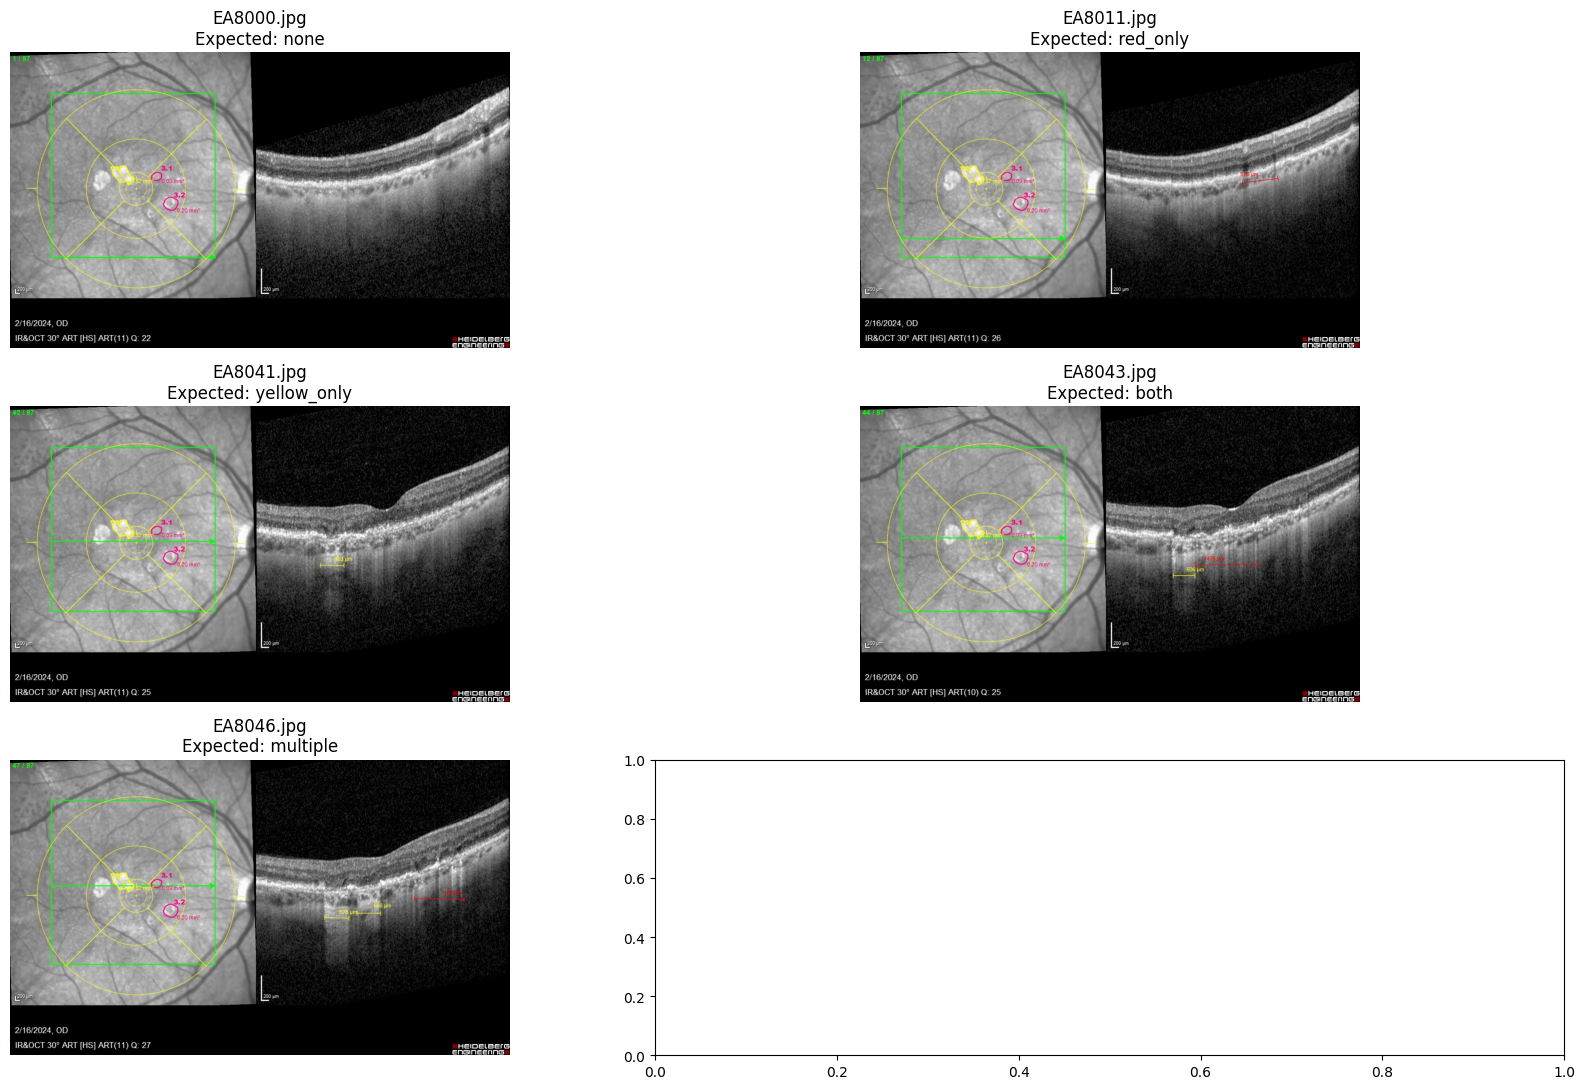

In [53]:
fig, axes = plt.subplots(
    nrows=3,
    ncols=2,
    figsize=(18, 11),
)

axes = axes.ravel()

for ax, (expected_label, image) in zip(axes, images.items()):
    image_rgb = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

    ax.imshow(image_rgb)
    ax.set_title(
        f"{TEST_FILES[expected_label].name}\n"
        f"Expected: {expected_label}"
    )
    ax.axis("off")

plt.tight_layout()
plt.show()

In [54]:
# Crop the right OCT panel
# Initial fractional crop boundaries.
#
# Adjust these after inspecting the crop visualization below.
OCT_X_MIN_FRAC = 0.49
OCT_X_MAX_FRAC = 0.995

OCT_Y_MIN_FRAC = 0.07
OCT_Y_MAX_FRAC = 0.82


def crop_oct_panel(
    image: np.ndarray,
    x_min_frac: float = OCT_X_MIN_FRAC,
    x_max_frac: float = OCT_X_MAX_FRAC,
    y_min_frac: float = OCT_Y_MIN_FRAC,
    y_max_frac: float = OCT_Y_MAX_FRAC,
) -> tuple[np.ndarray, dict]:
    """
    Crop the right-side OCT B-scan panel from a HEYEX JPG export.

    Returns
    -------
    crop
        Cropped OCT panel.

    crop_info
        Coordinates of the crop in the original JPG.
    """
    height, width = image.shape[:2]

    x_min = int(round(width * x_min_frac))
    x_max = int(round(width * x_max_frac))
    y_min = int(round(height * y_min_frac))
    y_max = int(round(height * y_max_frac))

    crop = image[y_min:y_max, x_min:x_max].copy()

    crop_info = {
        "x_offset": x_min,
        "y_offset": y_min,
        "x_min": x_min,
        "x_max": x_max,
        "y_min": y_min,
        "y_max": y_max,
        "crop_width": x_max - x_min,
        "crop_height": y_max - y_min,
    }

    return crop, crop_info

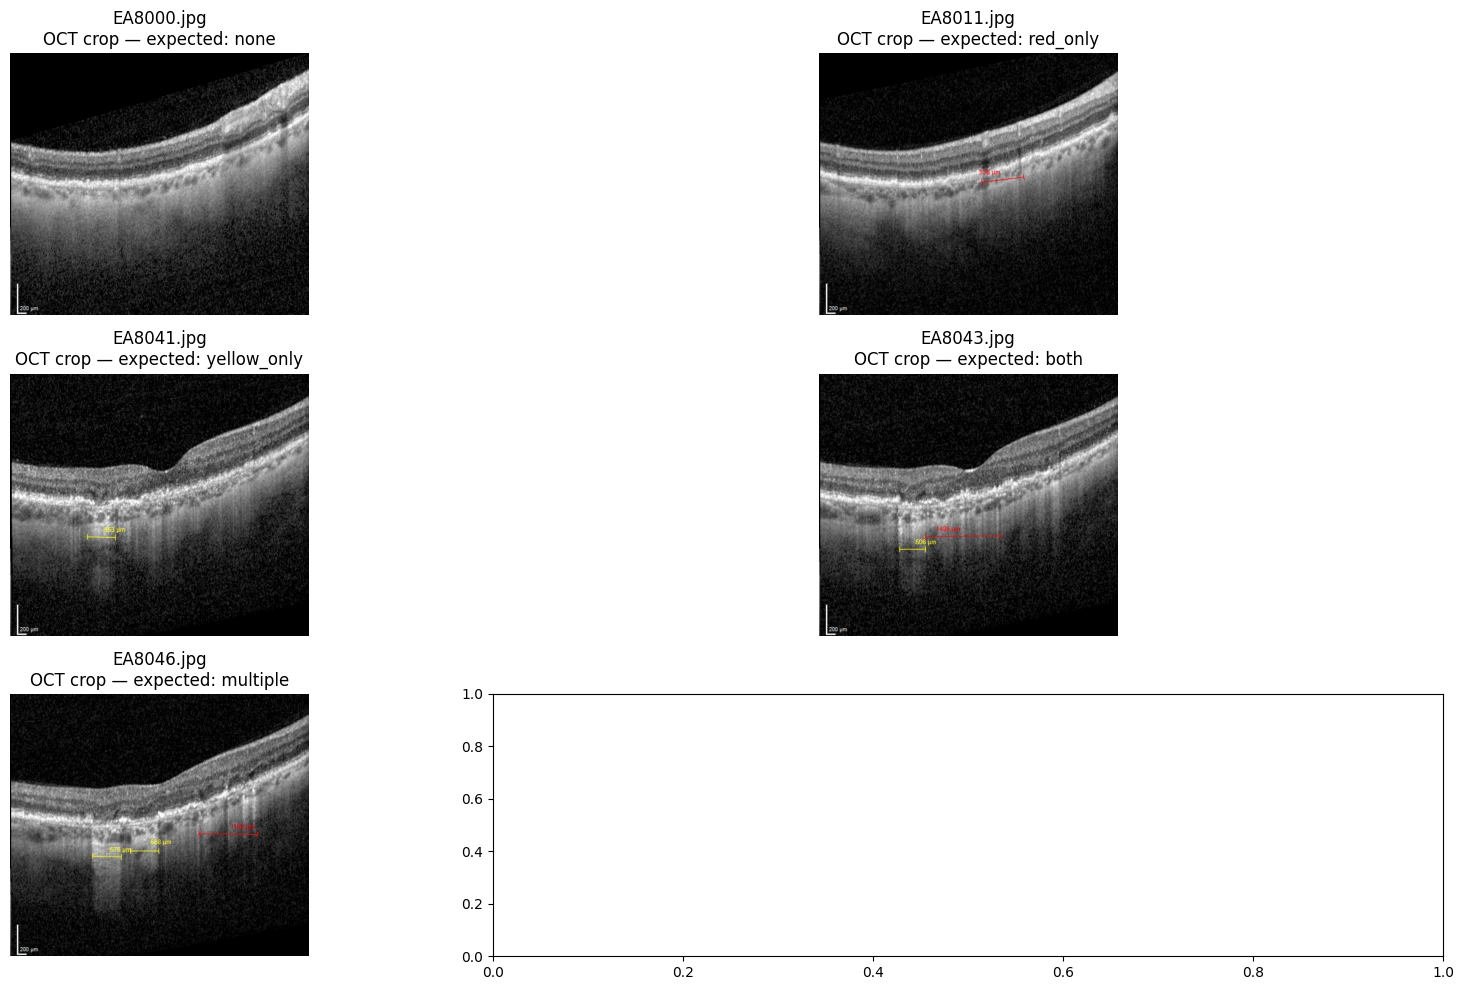

In [55]:
oct_crops = {}
crop_metadata = {}

fig, axes = plt.subplots(
    nrows=3,
    ncols=2,
    figsize=(18, 10),
)

axes = axes.ravel()

for ax, (expected_label, image) in zip(axes, images.items()):
    crop, crop_info = crop_oct_panel(image)

    oct_crops[expected_label] = crop
    crop_metadata[expected_label] = crop_info

    crop_rgb = cv2.cvtColor(crop, cv2.COLOR_BGR2RGB)

    ax.imshow(crop_rgb)
    ax.set_title(
        f"{TEST_FILES[expected_label].name}\n"
        f"OCT crop — expected: {expected_label}"
    )
    ax.axis("off")

plt.tight_layout()
plt.show()

In [56]:
#Define color masks
def create_color_masks(
    oct_crop: np.ndarray,
) -> tuple[np.ndarray, np.ndarray, np.ndarray]:
    """
    Create raw red and yellow masks from the cropped OCT panel.

    Returns
    -------
    hsv
        HSV representation of the OCT crop.

    red_mask
        Binary mask for red/magenta annotation pixels.

    yellow_mask
        Binary mask for yellow annotation pixels.
    """
    hsv = cv2.cvtColor(oct_crop, cv2.COLOR_BGR2HSV)

    # Red occupies both ends of OpenCV's hue range.
    red_lower_1 = np.array([0, 90, 80], dtype=np.uint8)
    red_upper_1 = np.array([15, 255, 255], dtype=np.uint8)

    red_lower_2 = np.array([155, 90, 80], dtype=np.uint8)
    red_upper_2 = np.array([179, 255, 255], dtype=np.uint8)

    red_mask_1 = cv2.inRange(
        hsv,
        red_lower_1,
        red_upper_1,
    )

    red_mask_2 = cv2.inRange(
        hsv,
        red_lower_2,
        red_upper_2,
    )

    red_mask = cv2.bitwise_or(
        red_mask_1,
        red_mask_2,
    )

    # Yellow annotation range.
    yellow_lower = np.array([18, 90, 100], dtype=np.uint8)
    yellow_upper = np.array([42, 255, 255], dtype=np.uint8)

    yellow_mask = cv2.inRange(
        hsv,
        yellow_lower,
        yellow_upper,
    )

    return hsv, red_mask, yellow_mask

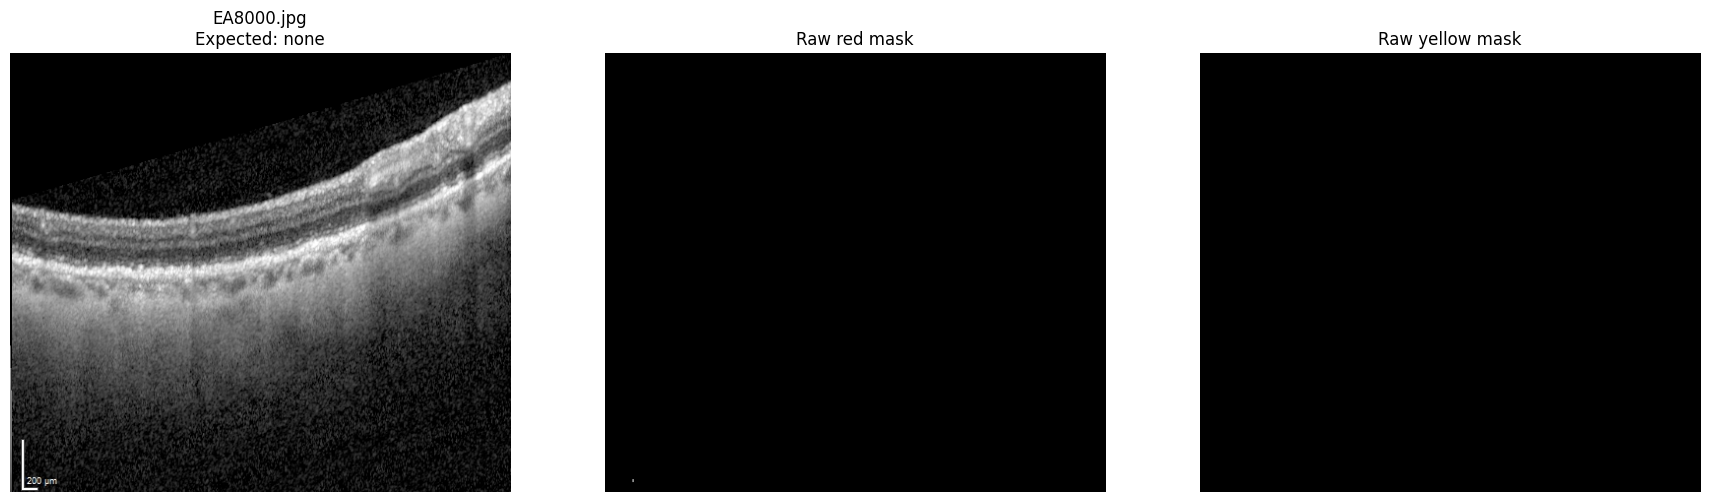

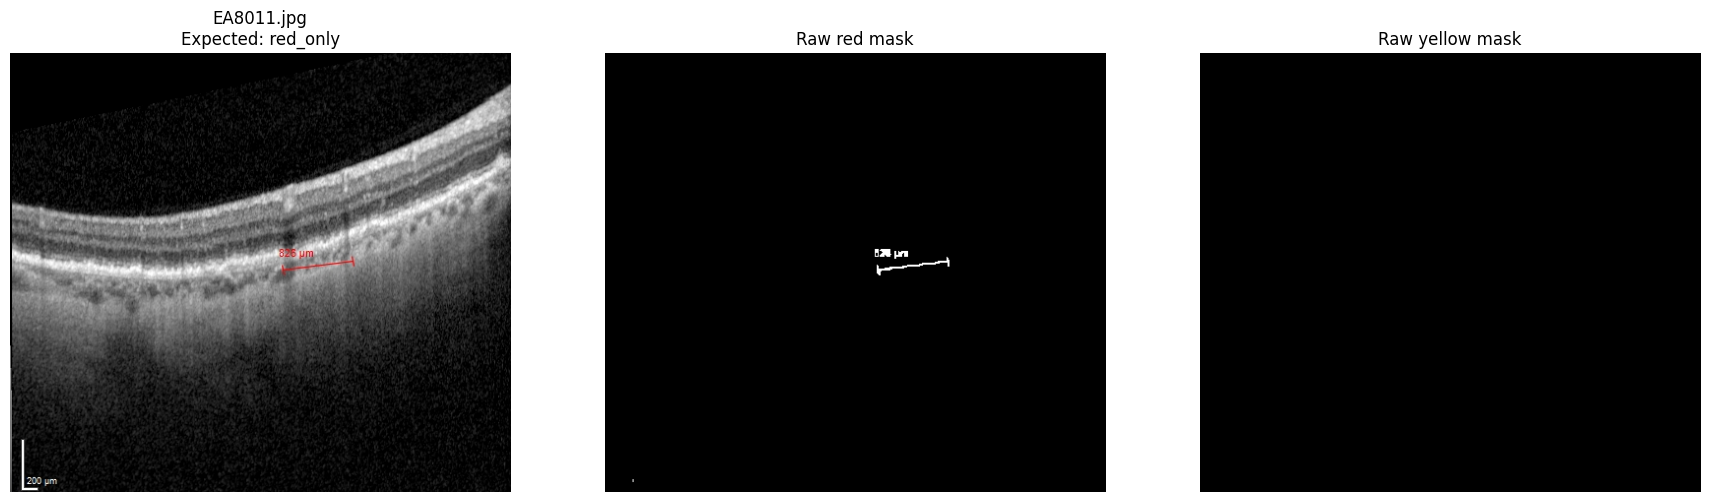

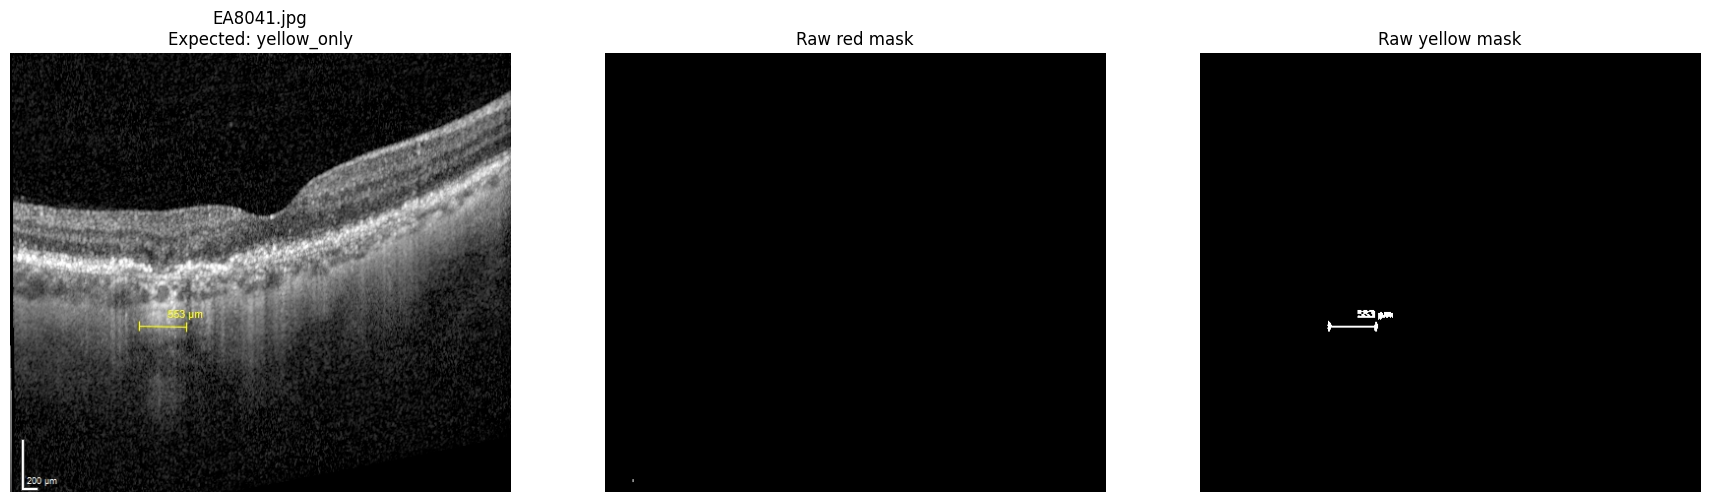

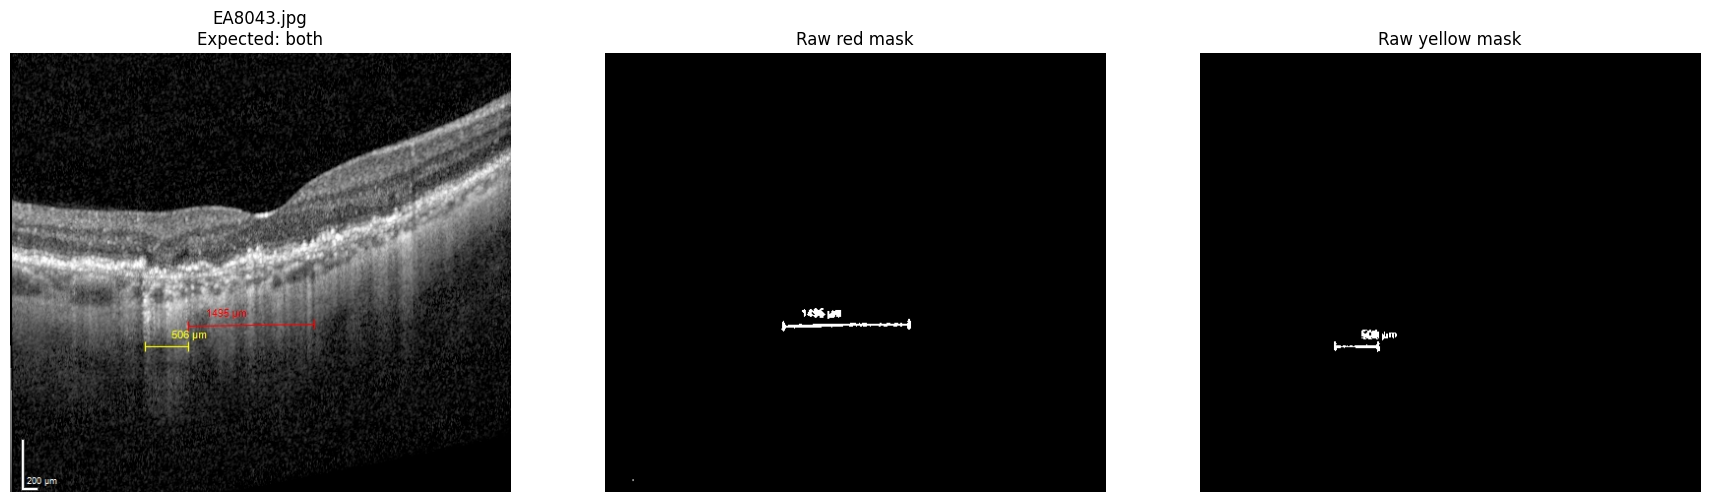

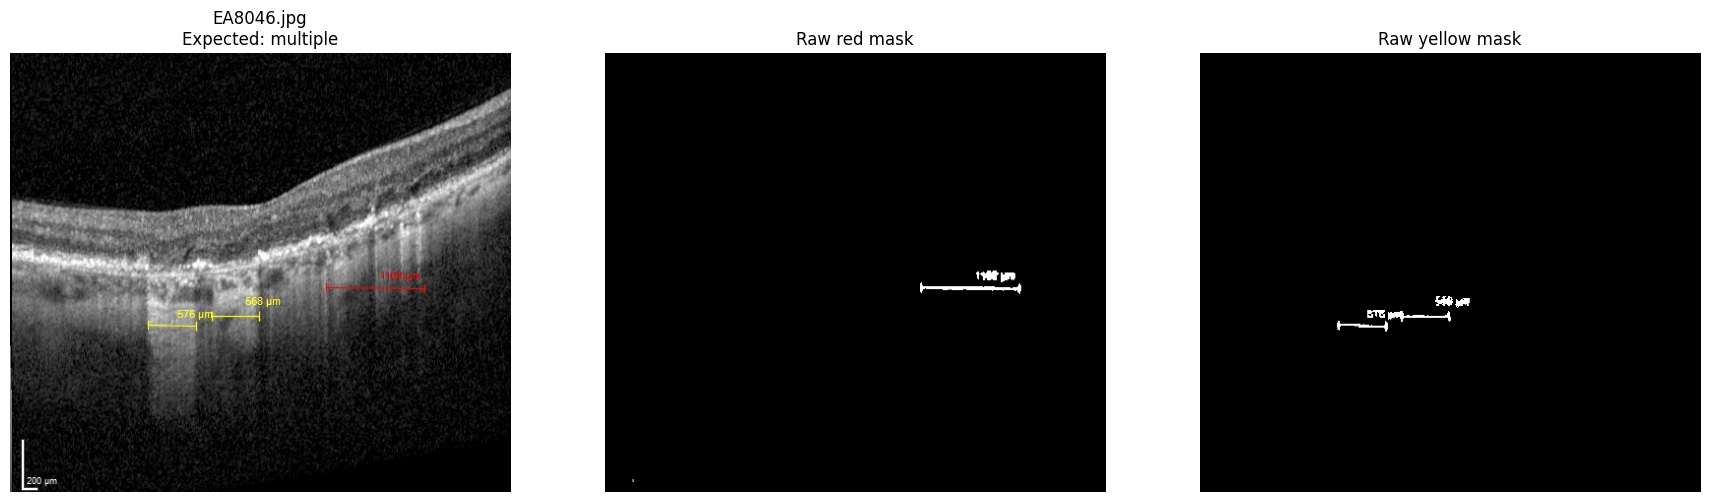

In [57]:
raw_masks = {}

for expected_label, crop in oct_crops.items():
    hsv, red_mask, yellow_mask = create_color_masks(crop)

    raw_masks[expected_label] = {
        "red": red_mask,
        "yellow": yellow_mask,
    }

    fig, axes = plt.subplots(
        nrows=1,
        ncols=3,
        figsize=(18, 5),
    )

    axes[0].imshow(
        cv2.cvtColor(crop, cv2.COLOR_BGR2RGB)
    )
    axes[0].set_title(
        f"{TEST_FILES[expected_label].name}\n"
        f"Expected: {expected_label}"
    )

    axes[1].imshow(red_mask, cmap="gray")
    axes[1].set_title("Raw red mask")

    axes[2].imshow(yellow_mask, cmap="gray")
    axes[2].set_title("Raw yellow mask")

    for ax in axes:
        ax.axis("off")

    plt.tight_layout()
    plt.show()

In [58]:
# Look for line structures
def isolate_horizontal_lines(
    mask: np.ndarray,
    horizontal_kernel_width: int = 15,
) -> np.ndarray:
    """
    Preserve long horizontal colored structures while removing most
    isolated text and JPEG artifacts.
    """
    binary_mask = (mask > 0).astype(np.uint8) * 255

    horizontal_kernel = cv2.getStructuringElement(
        cv2.MORPH_RECT,
        (horizontal_kernel_width, 1),
    )

    horizontal = cv2.morphologyEx(
        binary_mask,
        cv2.MORPH_OPEN,
        horizontal_kernel,
    )

    # Reconnect small breaks introduced by compression or text overlap.
    close_kernel = cv2.getStructuringElement(
        cv2.MORPH_RECT,
        (7, 3),
    )

    horizontal = cv2.morphologyEx(
        horizontal,
        cv2.MORPH_CLOSE,
        close_kernel,
    )

    return horizontal

In [59]:
def extract_line_components(
    line_mask: np.ndarray,
    color_label: str,
    min_width: int = 15,
    min_area: int = 10,
    min_aspect_ratio: float = 2.5,
) -> list[dict]:
    """
    Extract horizontal candidate components from a binary line mask.

    A single clinician measurement may initially appear as multiple
    components when annotation text interrupts the line.
    """
    num_labels, component_map, stats, _ = (
        cv2.connectedComponentsWithStats(
            line_mask,
            connectivity=8,
        )
    )

    segments = []

    for component_id in range(1, num_labels):
        x = int(stats[component_id, cv2.CC_STAT_LEFT])
        y = int(stats[component_id, cv2.CC_STAT_TOP])
        width = int(stats[component_id, cv2.CC_STAT_WIDTH])
        height = int(stats[component_id, cv2.CC_STAT_HEIGHT])
        area = int(stats[component_id, cv2.CC_STAT_AREA])

        aspect_ratio = width / max(height, 1)

        if width < min_width:
            continue

        if area < min_area:
            continue

        if aspect_ratio < min_aspect_ratio:
            continue

        component_pixels = component_map == component_id
        ys, xs = np.where(component_pixels)

        if len(xs) == 0:
            continue

        segments.append(
            {
                "color": color_label,
                "component_id": component_id,
                "x_start_crop": int(xs.min()),
                "x_end_crop": int(xs.max()),
                "y_mean_crop": float(ys.mean()),
                "y_min_crop": int(ys.min()),
                "y_max_crop": int(ys.max()),
                "length_px": int(xs.max() - xs.min() + 1),
                "bounding_x": x,
                "bounding_y": y,
                "bounding_width": width,
                "bounding_height": height,
                "pixel_area": area,
                "aspect_ratio": aspect_ratio,
            }
        )

    return sorted(
        segments,
        key=lambda segment: (
            segment["color"],
            segment["y_mean_crop"],
            segment["x_start_crop"],
        ),
    )

In [60]:
# Merge interuptted pieces of the same line
def merge_collinear_segments(
    segments: list[dict],
    max_horizontal_gap: int = 35,
    max_vertical_difference: float = 8.0,
) -> list[dict]:
    """
    Merge nearby components that likely belong to one clinician-drawn line.

    Two components are merged when they:
    - have the same color,
    - lie at nearly the same y-position,
    - overlap horizontally or have only a small gap.

    Parameters
    ----------
    segments
        Candidate line components.

    max_horizontal_gap
        Maximum number of pixels allowed between components.

    max_vertical_difference
        Maximum difference between mean y-coordinates.
    """
    if not segments:
        return []

    ordered = sorted(
        segments,
        key=lambda segment: (
            segment["color"],
            segment["y_mean_crop"],
            segment["x_start_crop"],
        ),
    )

    merged = []

    for segment in ordered:
        if not merged:
            merged.append(segment.copy())
            continue

        previous = merged[-1]

        same_color = previous["color"] == segment["color"]

        vertical_difference = abs(
            previous["y_mean_crop"]
            - segment["y_mean_crop"]
        )

        horizontal_gap = (
            segment["x_start_crop"]
            - previous["x_end_crop"]
            - 1
        )

        close_vertically = (
            vertical_difference <= max_vertical_difference
        )

        close_horizontally = (
            horizontal_gap <= max_horizontal_gap
        )

        if same_color and close_vertically and close_horizontally:
            previous_area = previous["pixel_area"]
            current_area = segment["pixel_area"]
            total_area = previous_area + current_area

            previous["x_start_crop"] = min(
                previous["x_start_crop"],
                segment["x_start_crop"],
            )

            previous["x_end_crop"] = max(
                previous["x_end_crop"],
                segment["x_end_crop"],
            )

            previous["y_mean_crop"] = (
                previous["y_mean_crop"] * previous_area
                + segment["y_mean_crop"] * current_area
            ) / total_area

            previous["y_min_crop"] = min(
                previous["y_min_crop"],
                segment["y_min_crop"],
            )

            previous["y_max_crop"] = max(
                previous["y_max_crop"],
                segment["y_max_crop"],
            )

            previous["length_px"] = (
                previous["x_end_crop"]
                - previous["x_start_crop"]
                + 1
            )

            previous["pixel_area"] = total_area

            previous["bounding_x"] = (
                previous["x_start_crop"]
            )

            previous["bounding_y"] = min(
                previous["bounding_y"],
                segment["bounding_y"],
            )

            previous["bounding_width"] = (
                previous["x_end_crop"]
                - previous["x_start_crop"]
                + 1
            )

            previous["bounding_height"] = (
                previous["y_max_crop"]
                - previous["y_min_crop"]
                + 1
            )

            previous["aspect_ratio"] = (
                previous["bounding_width"]
                / max(previous["bounding_height"], 1)
            )

            previous.setdefault(
                "merged_component_ids",
                [previous["component_id"]],
            )

            previous["merged_component_ids"].append(
                segment["component_id"]
            )

        else:
            new_segment = segment.copy()
            new_segment["merged_component_ids"] = [
                segment["component_id"]
            ]
            merged.append(new_segment)

    for segment in merged:
        segment.setdefault(
            "merged_component_ids",
            [segment["component_id"]],
        )

    return merged

def remove_measurement_text_components(
    segments: list[dict],
    max_vertical_separation: float = 18.0,
    min_horizontal_overlap_ratio: float = 0.20,
) -> list[dict]:
    """
    Remove colored measurement-text components located immediately above
    the actual horizontal measurement line.

    HEYEX places the numeric length label above the line. The text can
    survive horizontal morphology and appear as a short line component.

    A component is treated as text when another same-color component:
    - is below it,
    - is vertically close,
    - overlaps it horizontally,
    - and is longer.
    """
    if not segments:
        return []

    retained = []

    for candidate in segments:
        candidate_start = candidate["x_start_crop"]
        candidate_end = candidate["x_end_crop"]
        candidate_width = candidate["length_px"]
        candidate_y = candidate["y_mean_crop"]

        is_text_component = False

        for other in segments:
            if other is candidate:
                continue

            if other["color"] != candidate["color"]:
                continue

            other_start = other["x_start_crop"]
            other_end = other["x_end_crop"]
            other_width = other["length_px"]
            other_y = other["y_mean_crop"]

            # Actual measurement line should be below the text.
            vertical_separation = other_y - candidate_y

            if not (
                0 < vertical_separation <= max_vertical_separation
            ):
                continue

            overlap_start = max(
                candidate_start,
                other_start,
            )
            overlap_end = min(
                candidate_end,
                other_end,
            )

            overlap_width = max(
                0,
                overlap_end - overlap_start + 1,
            )

            overlap_ratio = (
                overlap_width / max(candidate_width, 1)
            )

            longer_component_below = (
                other_width > candidate_width
            )

            sufficient_overlap = (
                overlap_ratio >= min_horizontal_overlap_ratio
            )

            if longer_component_below and sufficient_overlap:
                is_text_component = True
                break

        if not is_text_component:
            retained.append(candidate.copy())

    return sorted(
        retained,
        key=lambda segment: (
            segment["color"],
            segment["y_mean_crop"],
            segment["x_start_crop"],
        ),
    )

In [61]:
experiment_results = []
cleaned_masks = {}
raw_component_results = {}
merged_component_results = {}
final_segment_results = {}

for expected_label, crop in oct_crops.items():
    path = TEST_FILES[expected_label]
    crop_info = crop_metadata[expected_label]

    _, red_raw, yellow_raw = create_color_masks(crop)

    red_lines = isolate_horizontal_lines(red_raw)
    yellow_lines = isolate_horizontal_lines(yellow_raw)

    cleaned_masks[expected_label] = {
        "red": red_lines,
        "yellow": yellow_lines,
    }

    # Step 1: raw horizontal components
    red_raw_segments = extract_line_components(
        line_mask=red_lines,
        color_label="red",
    )

    yellow_raw_segments = extract_line_components(
        line_mask=yellow_lines,
        color_label="yellow",
    )

    raw_component_results[expected_label] = {
        "red": red_raw_segments,
        "yellow": yellow_raw_segments,
    }

    # Step 2: merge only horizontally interrupted pieces
    red_merged = merge_collinear_segments(
        red_raw_segments,
        max_horizontal_gap=35,
        max_vertical_difference=5,
    )

    yellow_merged = merge_collinear_segments(
        yellow_raw_segments,
        max_horizontal_gap=35,
        max_vertical_difference=5,
    )

    merged_component_results[expected_label] = {
        "red": red_merged,
        "yellow": yellow_merged,
    }

    # Step 3: remove numeric measurement text above lines
    red_segments = remove_measurement_text_components(
        red_merged,
        max_vertical_separation=18,
        min_horizontal_overlap_ratio=0.20,
    )

    yellow_segments = remove_measurement_text_components(
        yellow_merged,
        max_vertical_separation=18,
        min_horizontal_overlap_ratio=0.20,
    )

    final_segment_results[expected_label] = {
        "red": red_segments,
        "yellow": yellow_segments,
    }

    all_segments = red_segments + yellow_segments

    for segment_index, segment in enumerate(
        all_segments,
        start=1,
    ):
        experiment_results.append(
            {
                "patient_id": PATIENT_ID,
                "filename": path.name,
                "expected_case": expected_label,
                "segment_index": segment_index,
                **segment,
                "x_start_jpg": (
                    segment["x_start_crop"]
                    + crop_info["x_offset"]
                ),
                "x_end_jpg": (
                    segment["x_end_crop"]
                    + crop_info["x_offset"]
                ),
                "y_mean_jpg": (
                    segment["y_mean_crop"]
                    + crop_info["y_offset"]
                ),
            }
        )

results_df = pd.DataFrame(experiment_results)

print("Finished extraction")
print(f"Detected {len(results_df)} final segments")

results_df[
    [
        "filename",
        "color",
        "x_start_crop",
        "x_end_crop",
        "y_mean_crop",
        "length_px",
    ]
]

Finished extraction
Detected 7 final segments


,filename,color,x_start_crop,x_end_crop,y_mean_crop,length_px
0,EA8011.jpg,red,276,349,216.579710,74
1,EA8041.jpg,yellow,130,180,278.500000,51
2,EA8043.jpg,red,180,310,277.128440,131
3,EA8043.jpg,yellow,136,182,299.000000,47
4,EA8046.jpg,red,320,422,239.469256,103
5,EA8046.jpg,yellow,170,254,267.259669,85
6,EA8046.jpg,yellow,139,190,277.564103,52


In [62]:
for expected_label, path in TEST_FILES.items():
    print("=" * 70)
    print(path.name)

    for color in ["red", "yellow"]:
        raw_segments = raw_component_results[
            expected_label
        ][color]

        merged_segments = merged_component_results[
            expected_label
        ][color]

        final_segments = final_segment_results[
            expected_label
        ][color]

        print(f"\n{color.upper()}")
        print(f"Raw components:    {len(raw_segments)}")
        print(f"After line merge:  {len(merged_segments)}")
        print(f"After text filter: {len(final_segments)}")

        for segment in final_segments:
            print(
                {
                    "length_px": segment["length_px"],
                    "x_start": segment["x_start_crop"],
                    "x_end": segment["x_end_crop"],
                    "y_mean": round(
                        segment["y_mean_crop"],
                        2,
                    ),
                    "source_components": (
                        segment["merged_component_ids"]
                    ),
                }
            )

EA8000.jpg

RED
Raw components:    0
After line merge:  0
After text filter: 0

YELLOW
Raw components:    0
After line merge:  0
After text filter: 0
EA8011.jpg

RED
Raw components:    1
After line merge:  1
After text filter: 1
{'length_px': 74, 'x_start': 276, 'x_end': 349, 'y_mean': 216.58, 'source_components': [1]}

YELLOW
Raw components:    0
After line merge:  0
After text filter: 0
EA8041.jpg

RED
Raw components:    0
After line merge:  0
After text filter: 0

YELLOW
Raw components:    3
After line merge:  3
After text filter: 1
{'length_px': 51, 'x_start': 130, 'x_end': 180, 'y_mean': 278.5, 'source_components': [3]}
EA8043.jpg

RED
Raw components:    2
After line merge:  2
After text filter: 1
{'length_px': 131, 'x_start': 180, 'x_end': 310, 'y_mean': 277.13, 'source_components': [2]}

YELLOW
Raw components:    2
After line merge:  2
After text filter: 1
{'length_px': 47, 'x_start': 136, 'x_end': 182, 'y_mean': 299.0, 'source_components': [2]}
EA8046.jpg

RED
Raw components:  

In [63]:
summary_rows = []

for expected_label, path in TEST_FILES.items():
    if results_df.empty:
        scan_rows = pd.DataFrame()
    else:
        scan_rows = results_df[
            results_df["filename"] == path.name
        ]

    if scan_rows.empty:
        n_red = 0
        n_yellow = 0
        red_lengths = []
        yellow_lengths = []
    else:
        red_rows = scan_rows[
            scan_rows["color"] == "red"
        ]
        yellow_rows = scan_rows[
            scan_rows["color"] == "yellow"
        ]

        n_red = len(red_rows)
        n_yellow = len(yellow_rows)

        red_lengths = (
            red_rows["length_px"]
            .astype(int)
            .tolist()
        )

        yellow_lengths = (
            yellow_rows["length_px"]
            .astype(int)
            .tolist()
        )

    summary_rows.append(
        {
            "filename": path.name,
            "expected_case": expected_label,
            "detected_red_segments": n_red,
            "detected_yellow_segments": n_yellow,
            "red_lengths_px": red_lengths,
            "yellow_lengths_px": yellow_lengths,
        }
    )

summary_df = pd.DataFrame(summary_rows)

summary_df

,filename,expected_case,detected_red_segments,detected_yellow_segments,red_lengths_px,yellow_lengths_px
0,EA8000.jpg,none,0,0,[],[]
1,EA8011.jpg,red_only,1,0,[74],[]
2,EA8041.jpg,yellow_only,0,1,[],[51]
3,EA8043.jpg,both,1,1,[131],[47]
4,EA8046.jpg,multiple,1,2,[103],"[85, 52]"


In [64]:
# draw detected segments on crops
def draw_detected_segments(
    crop: np.ndarray,
    segments: list[dict],
) -> np.ndarray:
    """
    Draw detected component endpoints and bounding boxes on the OCT crop.
    """
    output = crop.copy()

    for segment in segments:
        x_start = int(segment["x_start_crop"])
        x_end = int(segment["x_end_crop"])
        y_mean = int(round(segment["y_mean_crop"]))

        box_x = int(segment["bounding_x"])
        box_y = int(segment["bounding_y"])
        box_w = int(segment["bounding_width"])
        box_h = int(segment["bounding_height"])

        # These colors are only for our QC overlay.
        if segment["color"] == "red":
            display_color = (255, 0, 255)
        else:
            display_color = (255, 255, 0)

        cv2.rectangle(
            output,
            (box_x, box_y),
            (box_x + box_w - 1, box_y + box_h - 1),
            display_color,
            thickness=2,
        )

        cv2.circle(
            output,
            (x_start, y_mean),
            radius=4,
            color=display_color,
            thickness=-1,
        )

        cv2.circle(
            output,
            (x_end, y_mean),
            radius=4,
            color=display_color,
            thickness=-1,
        )

        label_text = (
            f"{segment['color']}: "
            f"{segment['length_px']} px"
        )

        cv2.putText(
            output,
            label_text,
            (x_start, max(y_mean - 10, 15)),
            cv2.FONT_HERSHEY_SIMPLEX,
            0.45,
            display_color,
            1,
            cv2.LINE_AA,
        )

    return output

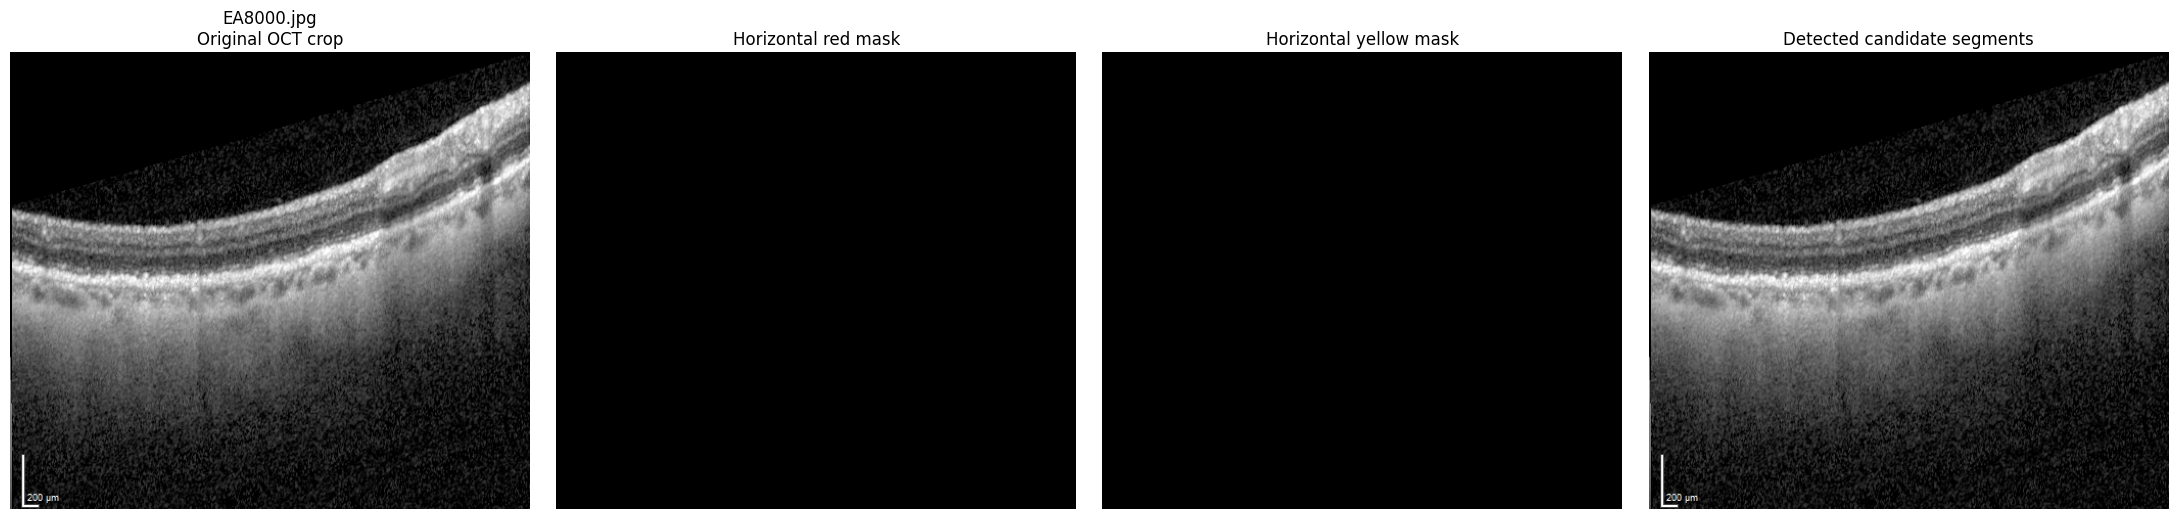

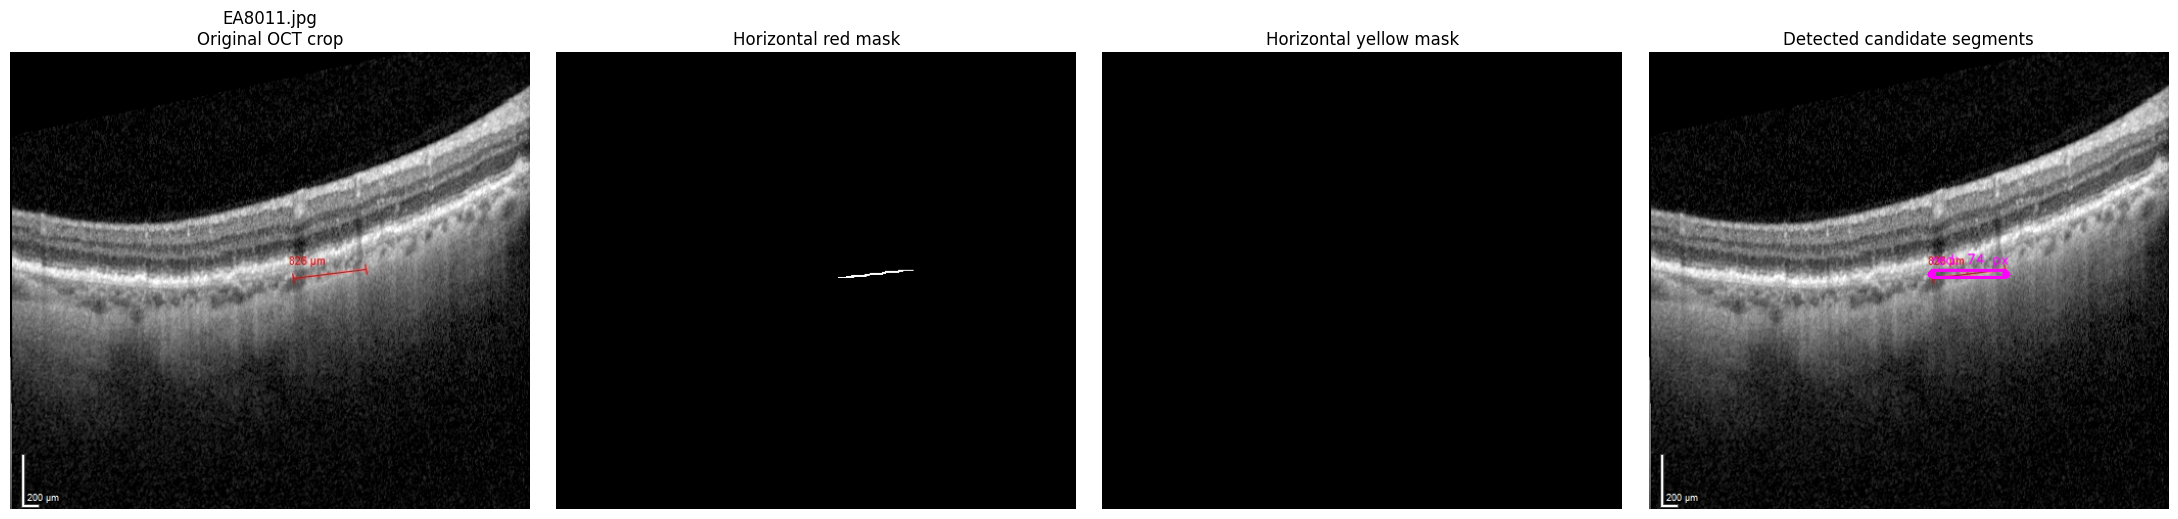

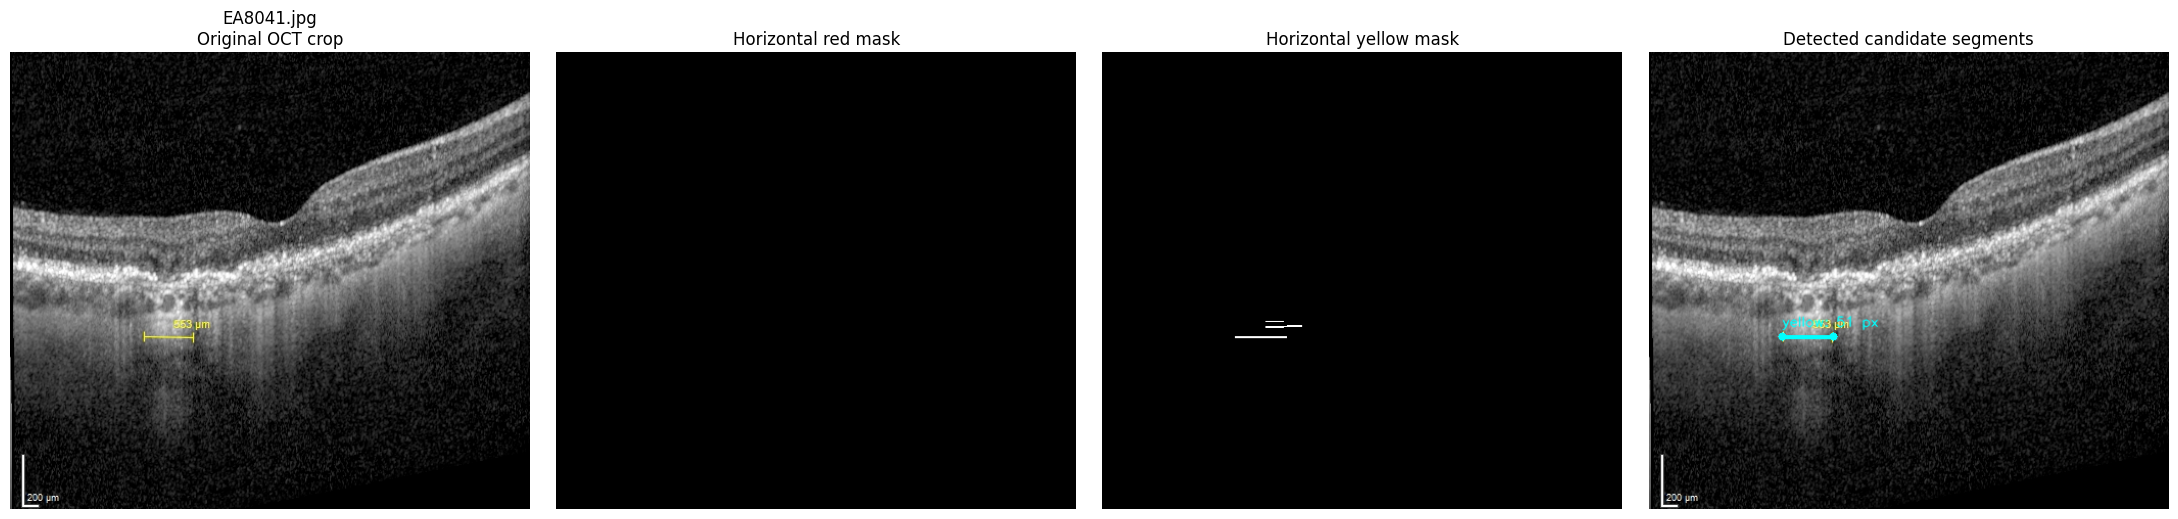

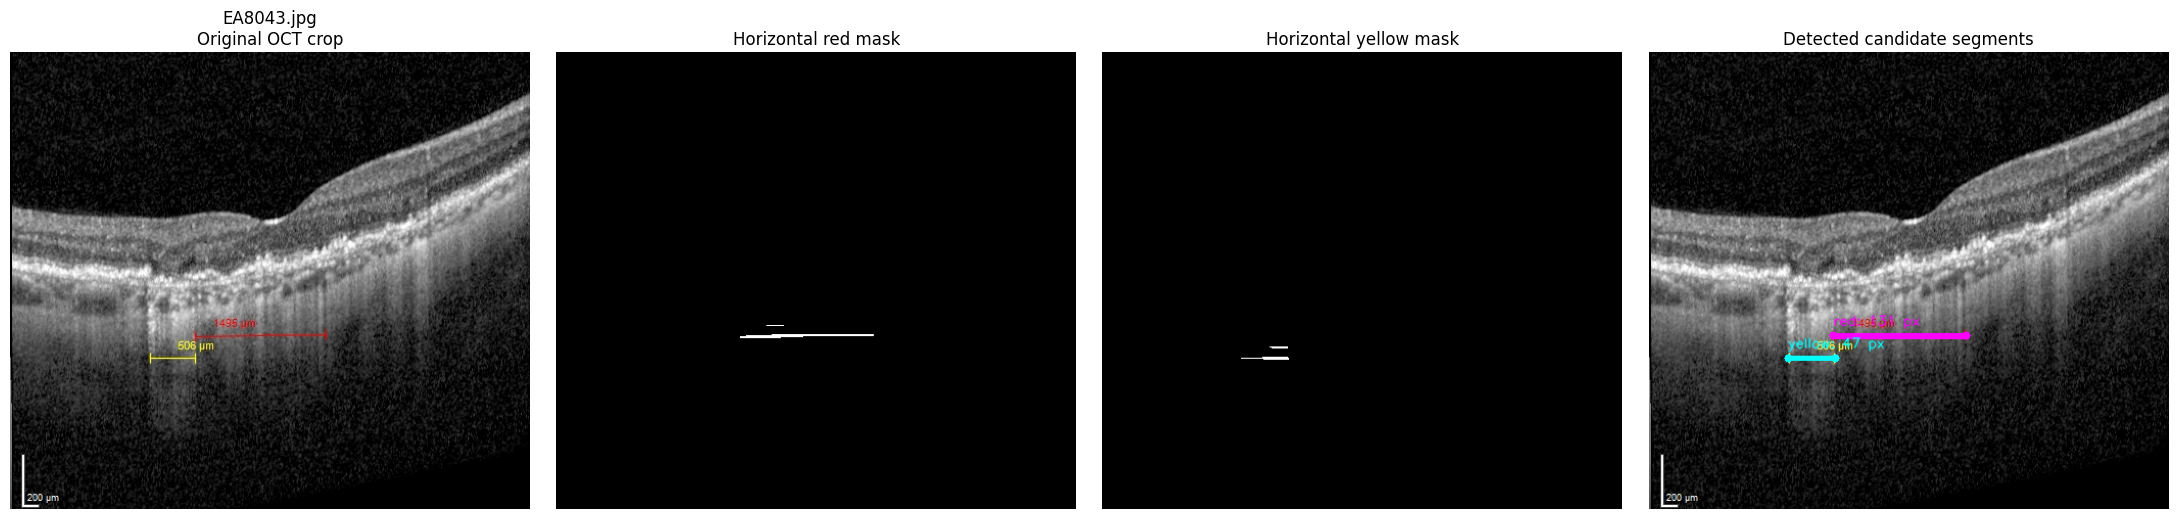

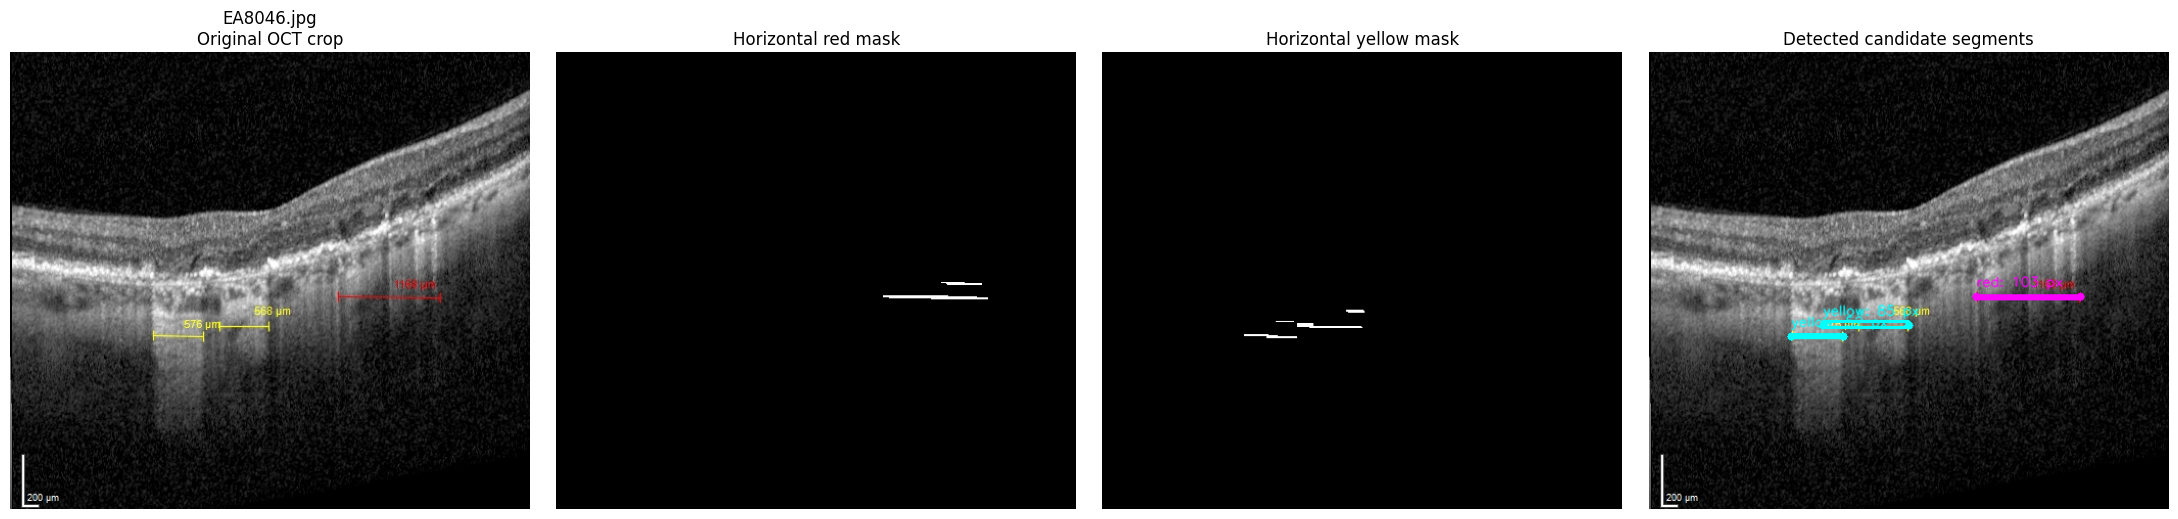

In [65]:
# inspect original, masks, and final detection
for expected_label, crop in oct_crops.items():
    filename = TEST_FILES[expected_label].name

    if results_df.empty:
        scan_segments = []
    else:
        scan_segments = (
            results_df[
                results_df["filename"] == filename
            ]
            .to_dict(orient="records")
        )

    overlay = draw_detected_segments(
        crop=crop,
        segments=scan_segments,
    )

    fig, axes = plt.subplots(
        nrows=1,
        ncols=4,
        figsize=(22, 5),
    )

    axes[0].imshow(
        cv2.cvtColor(crop, cv2.COLOR_BGR2RGB)
    )
    axes[0].set_title(
        f"{filename}\nOriginal OCT crop"
    )

    axes[1].imshow(
        cleaned_masks[expected_label]["red"],
        cmap="gray",
    )
    axes[1].set_title("Horizontal red mask")

    axes[2].imshow(
        cleaned_masks[expected_label]["yellow"],
        cmap="gray",
    )
    axes[2].set_title("Horizontal yellow mask")

    axes[3].imshow(
        cv2.cvtColor(overlay, cv2.COLOR_BGR2RGB)
    )
    axes[3].set_title("Detected candidate segments")

    for ax in axes:
        ax.axis("off")

    plt.tight_layout()
    plt.show()

In [66]:
for expected_label, path in TEST_FILES.items():
    print("=" * 70)
    print(f"File:     {path.name}")
    print(f"Expected: {expected_label}")

    if results_df.empty:
        scan_rows = pd.DataFrame()
    else:
        scan_rows = results_df[
            results_df["filename"] == path.name
        ]

    if scan_rows.empty:
        print("Detected segments: none")
        continue

    display_columns = [
        "color",
        "length_px",
        "x_start_crop",
        "x_end_crop",
        "y_mean_crop",
        "bounding_width",
        "bounding_height",
        "aspect_ratio",
    ]

    print(
        scan_rows[display_columns]
        .sort_values(["color", "x_start_crop"])
        .to_string(index=False)
    )

File:     EA8000.jpg
Expected: none
Detected segments: none
File:     EA8011.jpg
Expected: red_only
color  length_px  x_start_crop  x_end_crop  y_mean_crop  bounding_width  bounding_height  aspect_ratio
  red         74           276         349    216.57971              74                8          9.25
File:     EA8041.jpg
Expected: yellow_only
 color  length_px  x_start_crop  x_end_crop  y_mean_crop  bounding_width  bounding_height  aspect_ratio
yellow         51           130         180        278.5              51                2          25.5
File:     EA8043.jpg
Expected: both
 color  length_px  x_start_crop  x_end_crop  y_mean_crop  bounding_width  bounding_height  aspect_ratio
   red        131           180         310    277.12844             131                4     32.750000
yellow         47           136         182    299.00000              47                3     15.666667
File:     EA8046.jpg
Expected: multiple
 color  length_px  x_start_crop  x_end_crop  y_mean_cro

Those are the visible horizontal spans, not yet the physical micrometer values printed by HEYEX. The later E2E integration can provide the pixel-to-micron scaling, or we can validate the conversion immediately using the printed values.

# Pixel to Micron Conversion (merge with e2e)

Use the E2E file to extract:
* native B-scan pixel width,
* physical scan width in millimeters or microns,
* B-scan index ordering,
* any horizontal scale information available.

Compute Microns per pixel, noting the JPG may be resized relative to the native B-scan:
$$
\text{Microns per JPG Pixel}=\frac{\text{physical scan width in microns}}{\text{native bscan width pixels}} \times \frac{\text{native bscan width pixels}}{\text{JPG OCT panel width pixels}}
$$

Ideally resulting in:
```
filename   color    detected_px   heyex_um   estimated_um   abs_error_um
EA8011     red      74            836        ...
EA8041     yellow   51            553        ...
EA8043     red      131           1495       ...
EA8043     yellow   47            506        ...
```

In [67]:
from pathlib import Path
import eyepy as ep

e2e_path = Path("../data/heyex/meta/ea8.E2E")

volume = ep.import_heyex_e2e(e2e_path)

volume

In [68]:
print(type(volume))

print("\nVolume shape:")
print(volume.shape)

print("\nAvailable attributes:")
print(sorted(a for a in dir(volume) if not a.startswith("_")))

<class 'eyepy.core.eyevolume.EyeVolume'>

Volume shape:
(97, 496, 512)

Available attributes:
['add_layer_annotation', 'add_pixel_annotation', 'add_slab_annotation', 'data', 'data_par', 'intensity_transform', 'laterality', 'layers', 'load', 'localizer', 'localizer_transform', 'meta', 'par_algorithm', 'plot', 'remove_layer_annotation', 'remove_pixel_annotation', 'remove_slab_annotation', 'save', 'scale', 'scale_unit', 'scale_x', 'scale_y', 'scale_z', 'set_intensity_transform', 'set_par_algorithm', 'shape', 'size_x', 'size_y', 'size_z', 'slabs', 'volume_maps']


In [69]:
# inspect metadata
print(type(volume.meta))

print(volume.meta)

# If in a dictionary:
# for key, value in volume.meta.items():
#     print(f"{key:30s} : {value}")

<class 'eyepy.core.eyemeta.EyeVolumeMeta'>
scale_z: 1
scale_x: 1
scale_y: 1
scale_unit: px
bscan_meta: [start_pos: (-10.046368598937988, 9.411185264587402)
end_pos: (9.966765403747559, 10.054205894470215)
pos_unit: °
unknown0: 23
size_y: 496
size_x: 512
start_x: -10.046368598937988
start_y: 9.411185264587402
end_x: 9.966765403747559
end_y: 10.054205894470215
zero1: 0
unknown1: 42957136.0
scale_y: 0.0038716699928045273
unknown2: 1.0
zero2: 0
unknown3: ListContainer: 
    5970.43310546875
    108.75303649902344
zero3: 0
imgSizeWidth: 512
n_bscans: 97
aktImage: 0
scan_pattern: 1
center_x: -0.039801597595214844
center_y: 9.732695579528809
unknown4: 1
acquisitionTime: 2024-02-16T23:22:28.761000
numAve: 0
quality: 0.8416000008583069
unknown5: 0.9146999716758728, start_pos: (-10.040343284606934, 9.205114364624023)
end_pos: (9.972790718078613, 9.848134994506836)
pos_unit: °
unknown0: 23
size_y: 496
size_x: 512
start_x: -10.040343284606934
start_y: 9.205114364624023
end_x: 9.972790718078613
end

In [70]:
print(f"Number of B-scans: {len(volume)}")

bscan = volume[0]

print(type(bscan))

print("\nBscan attributes:")
print(sorted(a for a in dir(bscan) if not a.startswith("_")))

Number of B-scans: 97
<class 'eyepy.core.eyebscan.EyeBscan'>

Bscan attributes:
['area_maps', 'data', 'index', 'layers', 'meta', 'plot', 'scale_x', 'scale_y', 'shape', 'size_x', 'size_y', 'slabs', 'volume']


In [71]:
for attr in dir(bscan):

    if attr.startswith("_"):
        continue

    try:
        value = getattr(bscan, attr)

        if callable(value):
            continue

        print(f"{attr:30s} : {value}")

    except Exception:
        pass

area_maps                      : {}
data                           : [[38 18 28 ...  0  1  1]
 [56 41 31 ...  0  0  0]
 [85 58 41 ...  0  0  0]
 ...
 [ 0  0  0 ...  0  0  0]
 [ 0  0  0 ...  0  0  0]
 [ 0  0  0 ...  0  0  0]]
index                          : 0
layers                         : {}
meta                           : start_pos: (-10.046368598937988, 9.411185264587402)
end_pos: (9.966765403747559, 10.054205894470215)
pos_unit: °
unknown0: 23
size_y: 496
size_x: 512
start_x: -10.046368598937988
start_y: 9.411185264587402
end_x: 9.966765403747559
end_y: 10.054205894470215
zero1: 0
unknown1: 42957136.0
scale_y: 0.0038716699928045273
unknown2: 1.0
zero2: 0
unknown3: ListContainer: 
    5970.43310546875
    108.75303649902344
zero3: 0
imgSizeWidth: 512
n_bscans: 97
aktImage: 0
scan_pattern: 1
center_x: -0.039801597595214844
center_y: 9.732695579528809
unknown4: 1
acquisitionTime: 2024-02-16T23:22:28.761000
numAve: 0
quality: 0.8416000008583069
unknown5: 0.9146999716758728
scale_x  

scale_x and scale_y being 1 is a default representation, not physical calibration. `unknown3` looks interesting, 5970 is really close to a Spectralis B scan width of 6000 microns, so we'll look at what unknown3 is

In [72]:
# Use the B-scan that corresponds to EA8041 (aktImage = 41)

bscan = volume[41]

print("index:", bscan.index)
print("shape:", bscan.shape)
print("scale_x:", bscan.scale_x)
print("scale_y:", bscan.scale_y)
print("size_x:", bscan.size_x)
print("size_y:", bscan.size_y)

print("\nMetadata:")
for k, v in vars(bscan.meta).items():
    print(f"{k:20s}: {v}")

index: 41
shape: (496, 512)
scale_x: 1
scale_y: 1
size_x: 512
size_y: 496

Metadata:
_store              : {'start_pos': (-9.799324989318848, 0.9622939825057983), 'end_pos': (10.2138090133667, 1.605315089225769), 'pos_unit': '°', 'unknown0': 23, 'size_y': 496, 'size_x': 512, 'start_x': -9.799324989318848, 'start_y': 0.9622939825057983, 'end_x': 10.2138090133667, 'end_y': 1.605315089225769, 'zero1': 0, 'unknown1': 66557856.0, 'scale_y': 0.0038716699928045273, 'unknown2': 1.0, 'zero2': 0, 'unknown3': ListContainer([5987.3955078125, 116.47171783447266]), 'zero3': 0, 'imgSizeWidth': 512, 'n_bscans': 97, 'aktImage': 41, 'scan_pattern': 1, 'center_x': 0.20724201202392578, 'center_y': 1.2838045358657837, 'unknown4': 1, 'acquisitionTime': '2024-02-16T23:22:36.250999', 'numAve': 0, 'quality': 0.8416000008583069, 'unknown5': 0.9146999716758728}


In [74]:
unknown3 = bscan.meta._store["unknown3"]
print(type(unknown3))
print(unknown3) 
print("first value:", unknown3[0])
print("last value:", unknown3[1])

<class 'construct.lib.containers.ListContainer'>
ListContainer: 
    5987.3955078125
    116.47171783447266
first value: 5987.3955078125
last value: 116.47171783447266


In [75]:
# Calculate candidate native scale
bscan_index = 41
bscan = volume[bscan_index]

physical_width_candidate_um = float(
    bscan.meta._store["unknown3"][0]
)

native_width_px = int(bscan.meta._store["size_x"])

native_um_per_px = (
    physical_width_candidate_um / native_width_px
)

print(f"B-scan index:             {bscan_index}")
print(f"Candidate physical width: {physical_width_candidate_um:.3f} µm")
print(f"Native width:             {native_width_px} px")
print(f"Candidate scale:           {native_um_per_px:.4f} µm/px")

B-scan index:             41
Candidate physical width: 5987.396 µm
Native width:             512 px
Candidate scale:           11.6941 µm/px


In [79]:
# inspect JPG OCT panel width
from pathlib import Path
import cv2

jpg_path = Path("../data/heyex/anno/008/EA8041.jpg")

image_bgr = cv2.imread(str(jpg_path))

if image_bgr is None:
    raise FileNotFoundError(f"Could not load {jpg_path}")

oct_crop, crop_info = crop_oct_panel(image_bgr)

jpg_oct_height, jpg_oct_width = oct_crop.shape[:2]

print(f"OCT crop size: {jpg_oct_width} x {jpg_oct_height}")
print(crop_info)


OCT crop size: 509 x 447
{'x_offset': 494, 'y_offset': 42, 'x_min': 494, 'x_max': 1003, 'y_min': 42, 'y_max': 489, 'crop_width': 509, 'crop_height': 447}


In [80]:
native_width_px = 512
physical_width_um = 5987.3955078125

jpg_width_px = jpg_oct_width

native_um_per_px = physical_width_um / native_width_px
jpg_um_per_px = physical_width_um / jpg_width_px

print(f"Native μm/px : {native_um_per_px:.4f}")
print(f"JPG μm/px    : {jpg_um_per_px:.4f}")

Native μm/px : 11.6941
JPG μm/px    : 11.7631


In [81]:
# calculate JPG scale
jpg_um_per_px = (
    physical_width_candidate_um / jpg_oct_width
)

jpg_to_native_ratio = (
    native_width_px / jpg_oct_width
)

print(f"Native µm/px:          {native_um_per_px:.4f}")
print(f"JPG-to-native ratio:   {jpg_to_native_ratio:.4f}")
print(f"JPG OCT-panel µm/px:   {jpg_um_per_px:.4f}")

Native µm/px:          11.6941
JPG-to-native ratio:   1.0059
JPG OCT-panel µm/px:   11.7631


In [82]:
# test ea41 against heyex
detected_length_px = 51
heyex_length_um = 553

estimated_length_um = (
    detected_length_px * jpg_um_per_px
)

signed_error_um = estimated_length_um - heyex_length_um
absolute_error_um = abs(signed_error_um)
percent_error = (
    absolute_error_um / heyex_length_um * 100
)

print(f"Detected length: {detected_length_px} px")
print(f"Estimated length: {estimated_length_um:.1f} µm")
print(f"HEYEX length:     {heyex_length_um:.1f} µm")
print(f"Signed error:     {signed_error_um:.1f} µm")
print(f"Absolute error:   {absolute_error_um:.1f} µm")
print(f"Percent error:    {percent_error:.2f}%")

Detected length: 51 px
Estimated length: 599.9 µm
HEYEX length:     553.0 µm
Signed error:     46.9 µm
Absolute error:   46.9 µm
Percent error:    8.48%


In [83]:
# test all known measurements
import pandas as pd

validation_df = pd.DataFrame(
    [
        {
            "filename": "EA8011.jpg",
            "bscan_index": 11,
            "color": "red",
            "length_px": 74,
            "heyex_um": 836,
        },
        {
            "filename": "EA8041.jpg",
            "bscan_index": 41,
            "color": "yellow",
            "length_px": 51,
            "heyex_um": 553,
        },
        {
            "filename": "EA8043.jpg",
            "bscan_index": 43,
            "color": "red",
            "length_px": 131,
            "heyex_um": 1495,
        },
        {
            "filename": "EA8043.jpg",
            "bscan_index": 43,
            "color": "yellow",
            "length_px": 47,
            "heyex_um": 506,
        },
    ]
)

validation_df

,filename,bscan_index,color,length_px,heyex_um
0,EA8011.jpg,11,red,74,836
1,EA8041.jpg,41,yellow,51,553
2,EA8043.jpg,43,red,131,1495
3,EA8043.jpg,43,yellow,47,506
